# RandomForest - Cadre methodologique modulaire

Ce notebook applique un cadre methodologique reproductible et modulaire avec un modele RandomForest.

Il permet de :
- definir des profils (donnees, pretraitement, representation, modele, evaluation),
- executer une pipeline coherente
- produire une fiche modele avec metriques et sorties graphiques.

In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline.extract import add_target, load_csv_features, load_mat_matrix
from pipeline.pretraitement import apply_preprocess, apply_target_discretization, prepare_splits_and_impute
from pipeline.visu_pretraitement import plot_feature_report, plot_preprocessing_report, plot_split_report
from pipeline.models import fit_final_model, run_hyperparam_search
from pipeline.evaluation import (
    evaluate_by_subject,
    evaluate_robustness,
    evaluate_test_set,
    plot_feature_importance,
    plot_pca_if_classification,
)
from pipeline.reporting import build_model_card, export_visual_report

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed globale: {SEED}")

Seed globale: 42


## 1) Profils modulaires

In [ ]:
# Ajuster ces profils pour chaque experience
# Template source: pipeline/config.md (markdown a copier-coller)

DATA_PROFILE = {
    "source": "csv",
    "file_path": r"../data/Indicateurs calculés/FullTimeIndicatorsMinutes1.csv",
    "subject_id_col": "Participant",
}

PREPROCESS_PROFILE = {
    "clip_quantiles": [0.01, 0.99],   # clip sur les features
    "imputation_strategy": "median",
    "drop_low_information_features": True,
    "min_valid_features": 1,
    "normalization": "standard",  # None / "standard" / "minmax"
    # Colonnes a exclure des features (insensible a la casse)
    "exclude_features": ["minute", "Minute"],
    # include_features : "all" ou liste de colonnees à inclure
    "include_features": [
        "Amp01X",
        "Amp01Y",
        "Amp01Z",
        "Amp04X",
        "Amp04Y", 
        "Amp04Z",
        "TotMovX",
        "TotMovY",
        "TotMovZ",
        "TotMovXYZ",
        "%Pow01X",
        "%Pow01Y",
        "%Pow01Z",
        "%Pow04X",
        "%Pow04Y",
        "%Pow04Z",
    ],
}

TARGET_PROFILE = {
    "source": "xlsx",
    "xlsx_path": r"../data/Questionnaires/FMS1_org.xlsx",
    "sheet_name": "Feuil1",
    "subject_id_col": "Sujet",
    "target_mode": "per_minute",
    "minute_columns": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "minute_col": "Minute",
    "clip_quantiles": None,           # clip sur la cible avant discretisation (ex: [0.01, 0.99]) — None = desactive
    "discretize": {                   # None pour regression
        "bins":   [0, 5, 10, 20],
        "labels": ["low", "medium", "high"],
    },
}

MODEL_PROFILE = {
    "model_type": "random_forest",  # random_forest / xgboost
    "task_type": "classification",  # classification / regression
    "split_method": "group",        # group / random
    "test_size": 0.20,
    "val_size": 0.20,
    "class_weight": "balanced",
    "random_state": SEED,
}

EVAL_PROFILE = {
    "robustness_noise_std": 0.01,
    "robustness_repeats": 5,
}

OUTPUT_PROFILE = {
    "output_dir": r"../data/outputs/random_forest",
    "save_model_card": True,
    "save_visual_report": True,
    "visual_report_format": "both",  # pdf / png / both
    "visual_report_name": "random_forest_head_report",
    # "all" pour tout, ou une liste explicite de fonctions
    "visual_report_functions": [
        "visual_cover_page",
        "visual_split_report",
        "visual_correlation_pages",
        "visual_confusion_matrix",
        "visual_feature_importance",
        "visual_pca",
        "visual_violin_pages",
    ],
    "max_corr_features": 32,
    "max_violin_features": 48,
    "violin_features_per_page": 10,
    "top_n_importance": 20, # nombre de features dans le graphe d'importance
    # Texte libre presente sur la page de garde du rapport visuel (optionnel)
    "hypothesis": (
        """
            Nous regardons ici la performance de random forest sur les données de mouvement de tête seulement.
        """
    ),
}

print("Profils charges depuis la cellule notebook (template config.py)")
print("Data source :", DATA_PROFILE["source"])
print("Modèle :", MODEL_PROFILE["model_type"])
print("Tache :", MODEL_PROFILE["task_type"])
print("Target source :", TARGET_PROFILE["source"])
print("Mode cible :", TARGET_PROFILE.get("target_mode", "n/a"))
print("Normalisation :", PREPROCESS_PROFILE.get("normalization") or "aucune")


Profils charges depuis la cellule notebook (template config.py)
Data source : csv
Modèle : random_forest
Tache : classification
Target source : xlsx
Mode cible : per_minute
Normalisation : standard


## 3) Construction de representation (Approche A ou B)

In [3]:
if DATA_PROFILE["source"] == "csv":
    features_df = load_csv_features(DATA_PROFILE)
    print("Source CSV detectee: les features sont chargees telles quelles.")

elif DATA_PROFILE["source"] == "mat":
    mat_dict, data_matrix, subject_ids = load_mat_matrix(DATA_PROFILE)
    raise NotImplementedError(
        "Le chemin MAT doit maintenant etre orchestre via des fonctions dediees dans rf_pipeline si necessaire."
    )

else:
    raise ValueError("DATA_PROFILE['source'] doit etre 'csv' ou 'mat'.")

print("Shape:", features_df.shape)
display(features_df.head())

Source CSV detectee: les features sont chargees telles quelles.
Shape: (574, 34)


,subject_id,Minute,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,...,%Pow01EyeX,%Pow01EyeY,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id
0,0933,1,0.138978,0.095120,0.016308,0.084265,0.100830,0.173925,2166.960484,9533.470190,...,2.561688,4.804704,0.038757,4.804704,0.123952,319.224603,3.333145,3.465322,1.587302,0
1,7180bt,1,0.391176,0.661502,0.023081,0.038081,0.352528,0.221892,5054.512261,6774.620885,...,2.062268,0.908652,0.858235,0.908652,0.070573,217.640225,3.777876,3.725042,17.126149,1
2,22009611,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,ab0710,1,0.060397,0.068861,0.002310,0.038956,0.153820,0.089738,647.350744,912.905124,...,1.433131,8.315259,2.756813,8.315259,0.159130,194.315384,4.082976,3.888957,2.172097,3
4,am3001,1,0.063596,0.014971,0.032345,0.095778,0.044423,0.032648,1922.915362,793.806587,...,10.938133,8.185577,0.215129,8.185577,0.103624,157.331180,5.250478,5.144878,0.751880,4


## 4) Integration de la cible

In [4]:
dataset_df = add_target(features_df, TARGET_PROFILE)

print("Dataset avec cible:", dataset_df.shape)
print("Apercu colonnes:", dataset_df.columns[:10].tolist())
display(dataset_df.head())

Dataset avec cible: (522, 36)
Apercu colonnes: ['subject_id', 'Minute', 'Amp01X', 'Amp01Y', 'Amp01Z', 'Amp04X', 'Amp04Y', 'Amp04Z', 'TotMovX', 'TotMovY']


,subject_id,Minute,Amp01X,Amp01Y,Amp01Z,Amp04X,Amp04Y,Amp04Z,TotMovX,TotMovY,...,%Pow04EyeX,%Pow04EyeY,Ellipse95Eye,Ellipse95WorldPos,PupilDiamX,PupilDiamY,%Boat,row_id,minute,target
0,7180bt,1,0.391176,0.661502,0.023081,0.038081,0.352528,0.221892,5054.512261,6774.620885,...,0.858235,0.908652,0.070573,217.640225,3.777876,3.725042,17.126149,1,1,7.0
1,22009611,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,4.0
2,ab0710,1,0.060397,0.068861,0.002310,0.038956,0.153820,0.089738,647.350744,912.905124,...,2.756813,8.315259,0.159130,194.315384,4.082976,3.888957,2.172097,3,1,8.0
3,am3001,1,0.063596,0.014971,0.032345,0.095778,0.044423,0.032648,1922.915362,793.806587,...,0.215129,8.185577,0.103624,157.331180,5.250478,5.144878,0.751880,4,1,3.0
4,AP1133,1,0.009319,0.003780,0.003951,0.003373,0.033734,0.053038,108.184186,114.219420,...,1.963714,31.873764,0.034554,41.801993,3.533532,3.688725,0.000000,5,1,4.0


## 5) Pretraitement, split et preparation

In [5]:

def display_target_info(df, model_profile, target_profile=None, preprocess_profile=None):
    task = model_profile.get("task_type", "regression")
    target = df["target"]

    if task == "classification":
        print("Classes:", sorted(target.dropna().unique().tolist()))
        print("Distribution:")
        print(target.value_counts().sort_index())
    else:
        print("Distribution cible (regression):")
        print(target.describe())

    if target_profile and target_profile.get("clip_quantiles"):
        q_low, q_high = target_profile["clip_quantiles"]
        print(f"\nClip quantiles cible   : [{q_low}, {q_high}]")
    if preprocess_profile and preprocess_profile.get("clip_quantiles"):
        q_low, q_high = preprocess_profile["clip_quantiles"]
        print(f"Clip quantiles features: [{q_low}, {q_high}]")


dataset_df = apply_target_discretization(dataset_df, TARGET_PROFILE)
display_target_info(dataset_df, MODEL_PROFILE, TARGET_PROFILE, PREPROCESS_PROFILE)

raw_df = dataset_df.copy()
dataset_df, feature_cols = apply_preprocess(dataset_df, PREPROCESS_PROFILE)

prepared = prepare_splits_and_impute(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    preprocess_profile=PREPROCESS_PROFILE,
    model_profile=MODEL_PROFILE,
)

X_train_imp = prepared["X_train_imp"]
X_val_imp = prepared["X_val_imp"]
X_test_imp = prepared["X_test_imp"]
y_train = prepared["y_train"]
y_val = prepared["y_val"]
y_test = prepared["y_test"]
train_idx = prepared["train_idx"]
val_idx = prepared["val_idx"]
test_idx = prepared["test_idx"]
imputer = prepared["imputer"]
scaler = prepared["scaler"]

print("\nDataset final:", dataset_df.shape)
print("Nombre de features:", len(feature_cols))
print("Split sizes -> train/val/test:", len(train_idx), len(val_idx), len(test_idx))
if scaler is not None:
    print("Normalisation appliquee:", type(scaler).__name__)


Classes: ['high', 'low', 'medium']
Distribution:
target
low       318
medium    153
high       51
Name: count, dtype: int64
Clip quantiles features: [0.01, 0.99]

Dataset final: (499, 36)
Nombre de features: 19
Split sizes -> train/val/test: 280 107 112
Normalisation appliquee: StandardScaler


## 5.bis) Visualisation du pretraitement

Shape avant prétraitement : (522, 36)
Shape après prétraitement : (499, 36)
Nombre de sujets exclus : 0
Nombre de features droppées (zero-variance) : 14
Nombre total de NaN avant imputation : 731
Seuils de clipping utilisés : [0.01, 0.99]


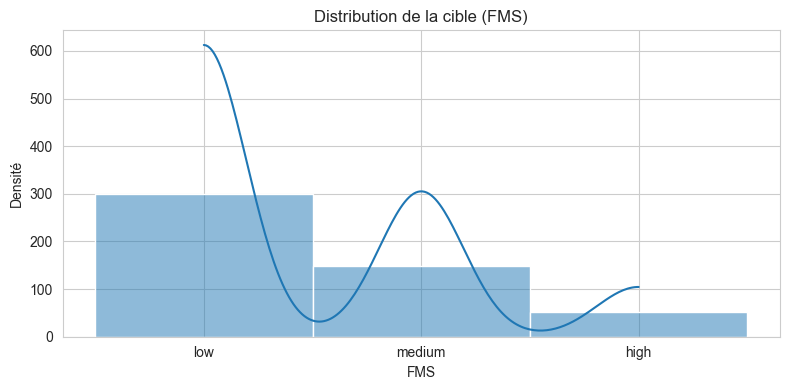

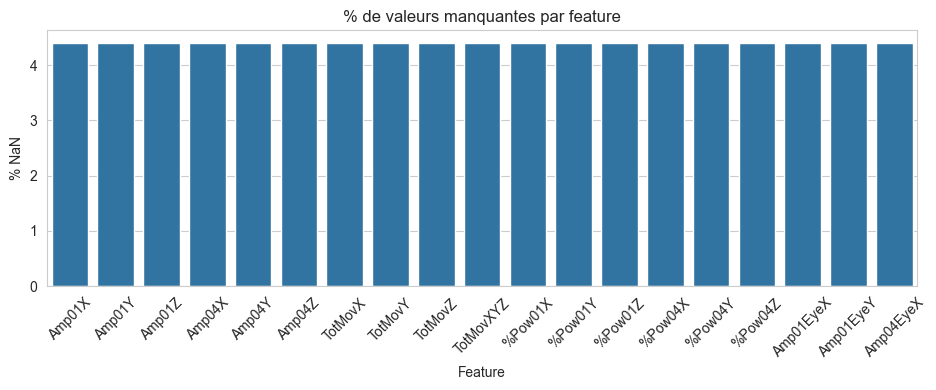

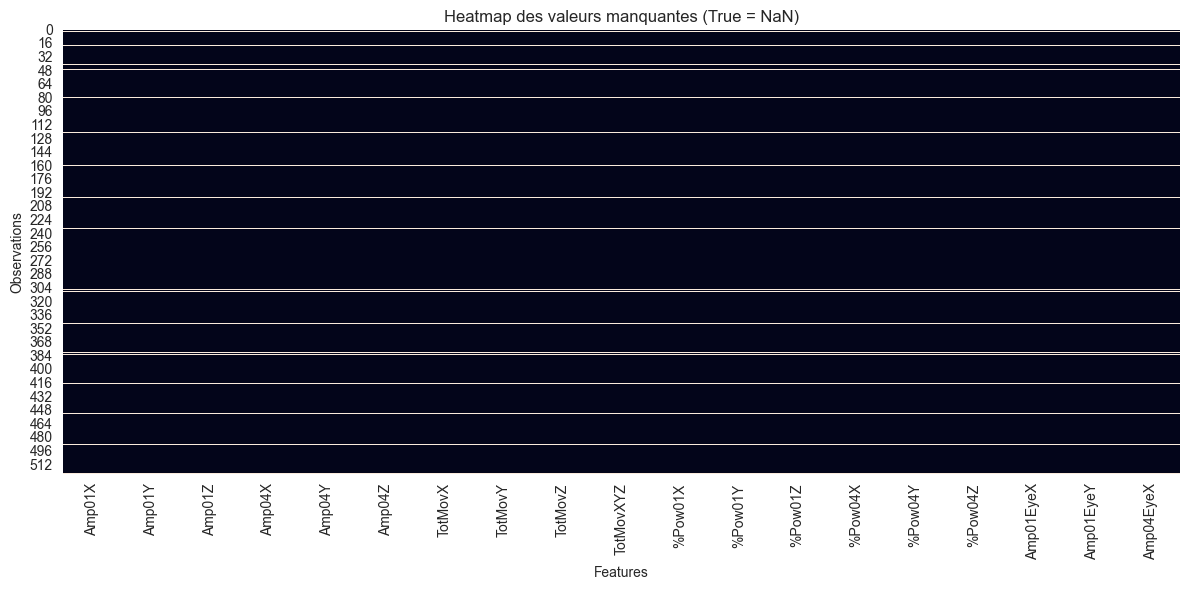

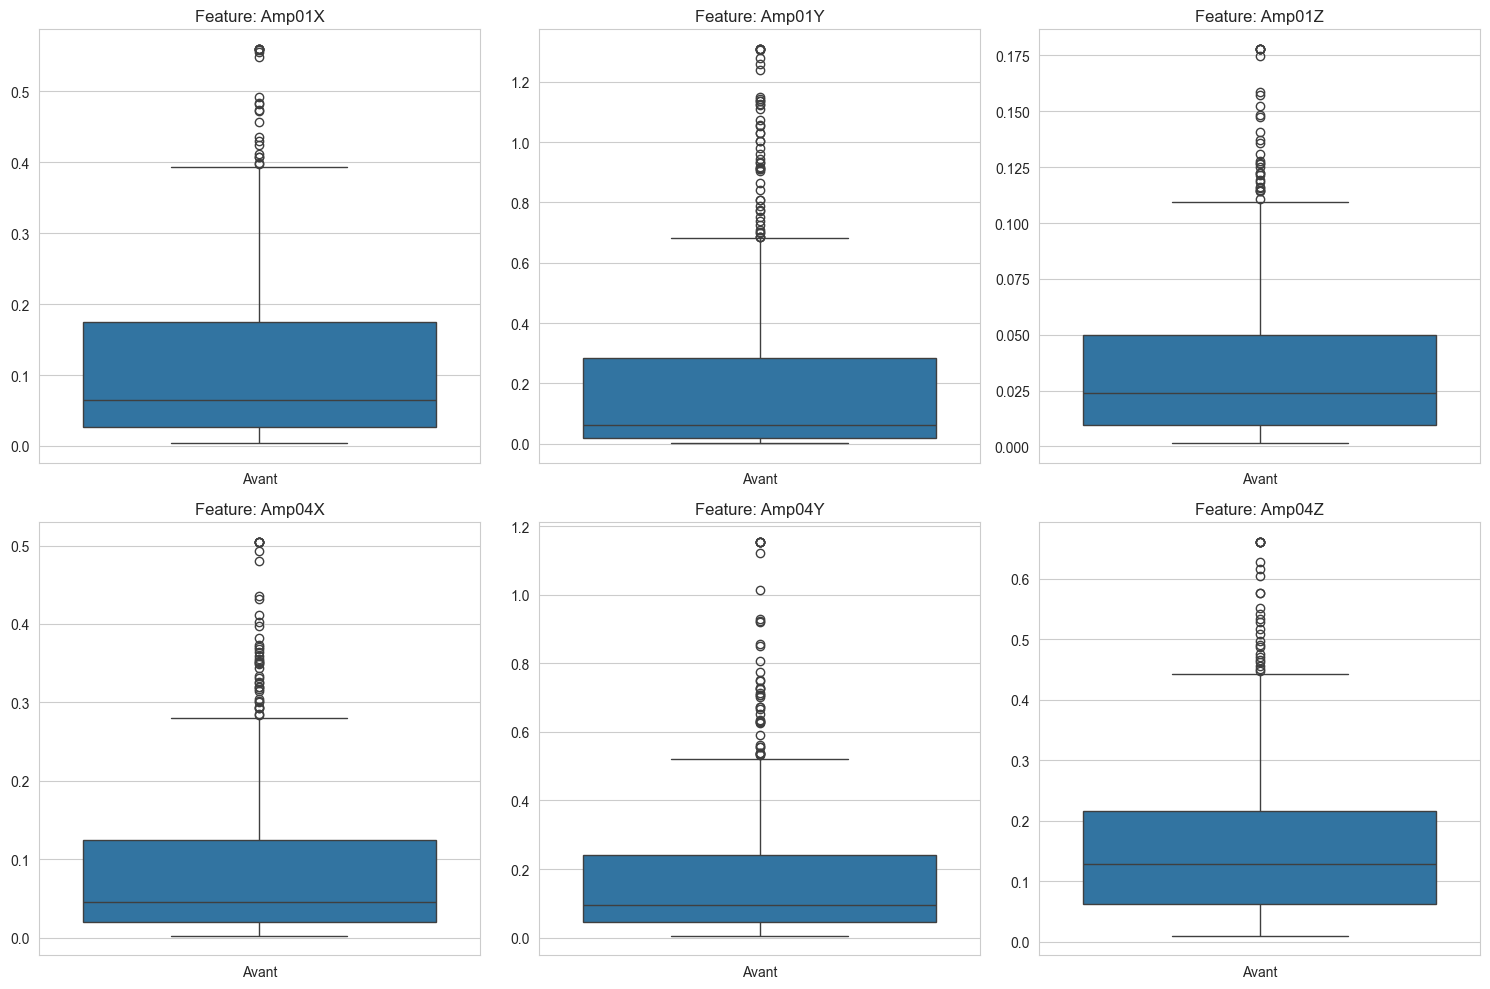

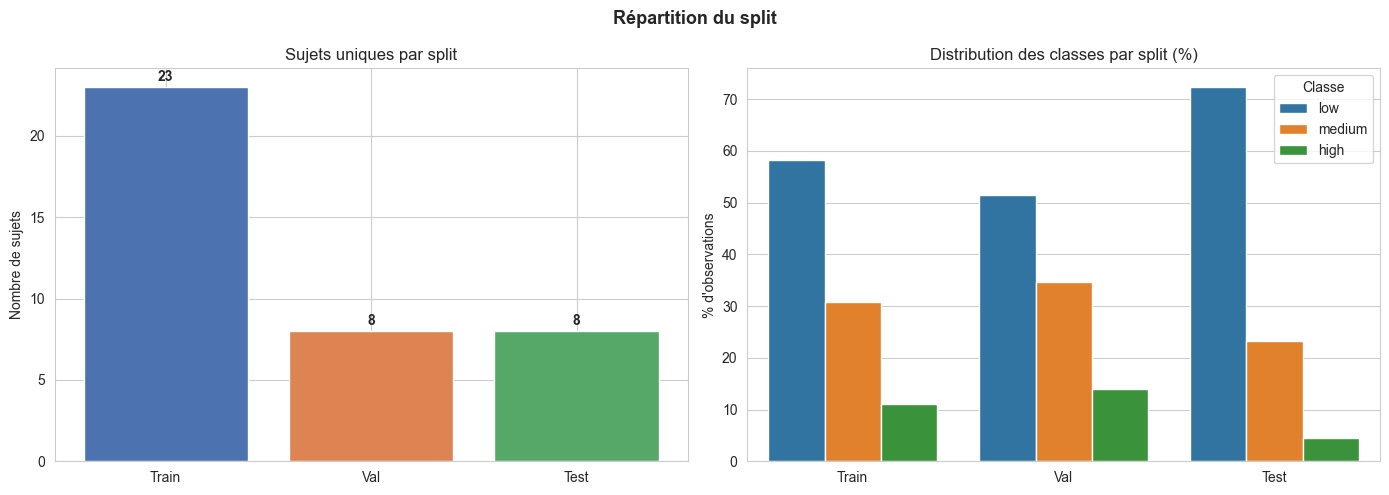

In [6]:
plot_preprocessing_report(raw_df, dataset_df, feature_cols, PREPROCESS_PROFILE)

plot_split_report(dataset_df, train_idx, val_idx, test_idx, MODEL_PROFILE)

## 5.ter) Visualisation des features

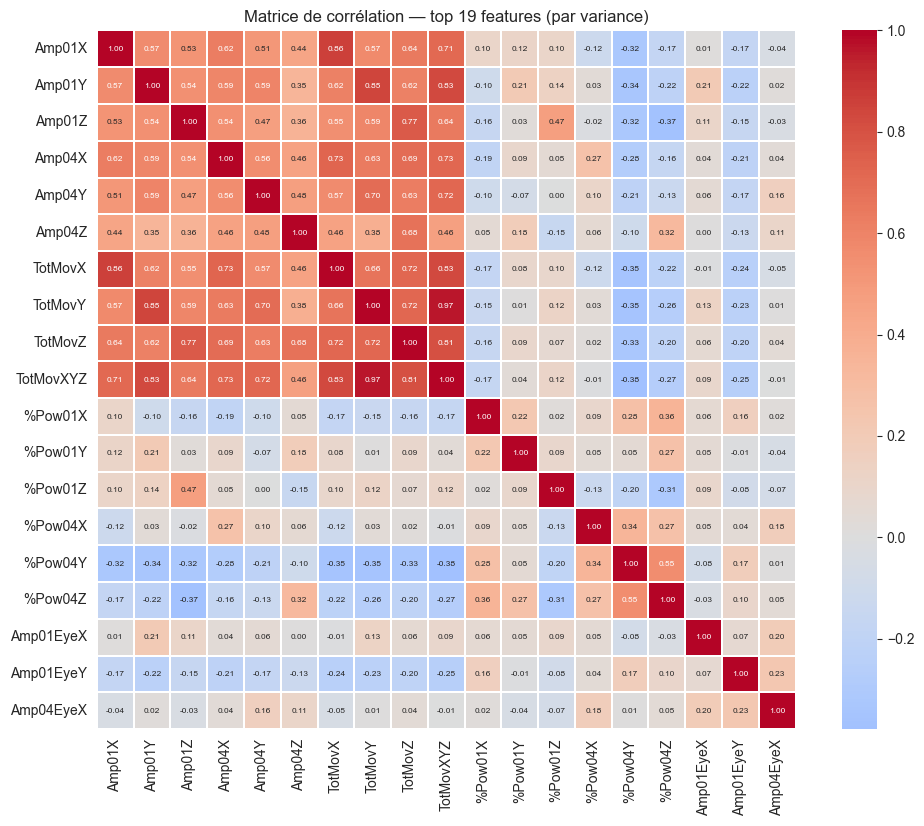

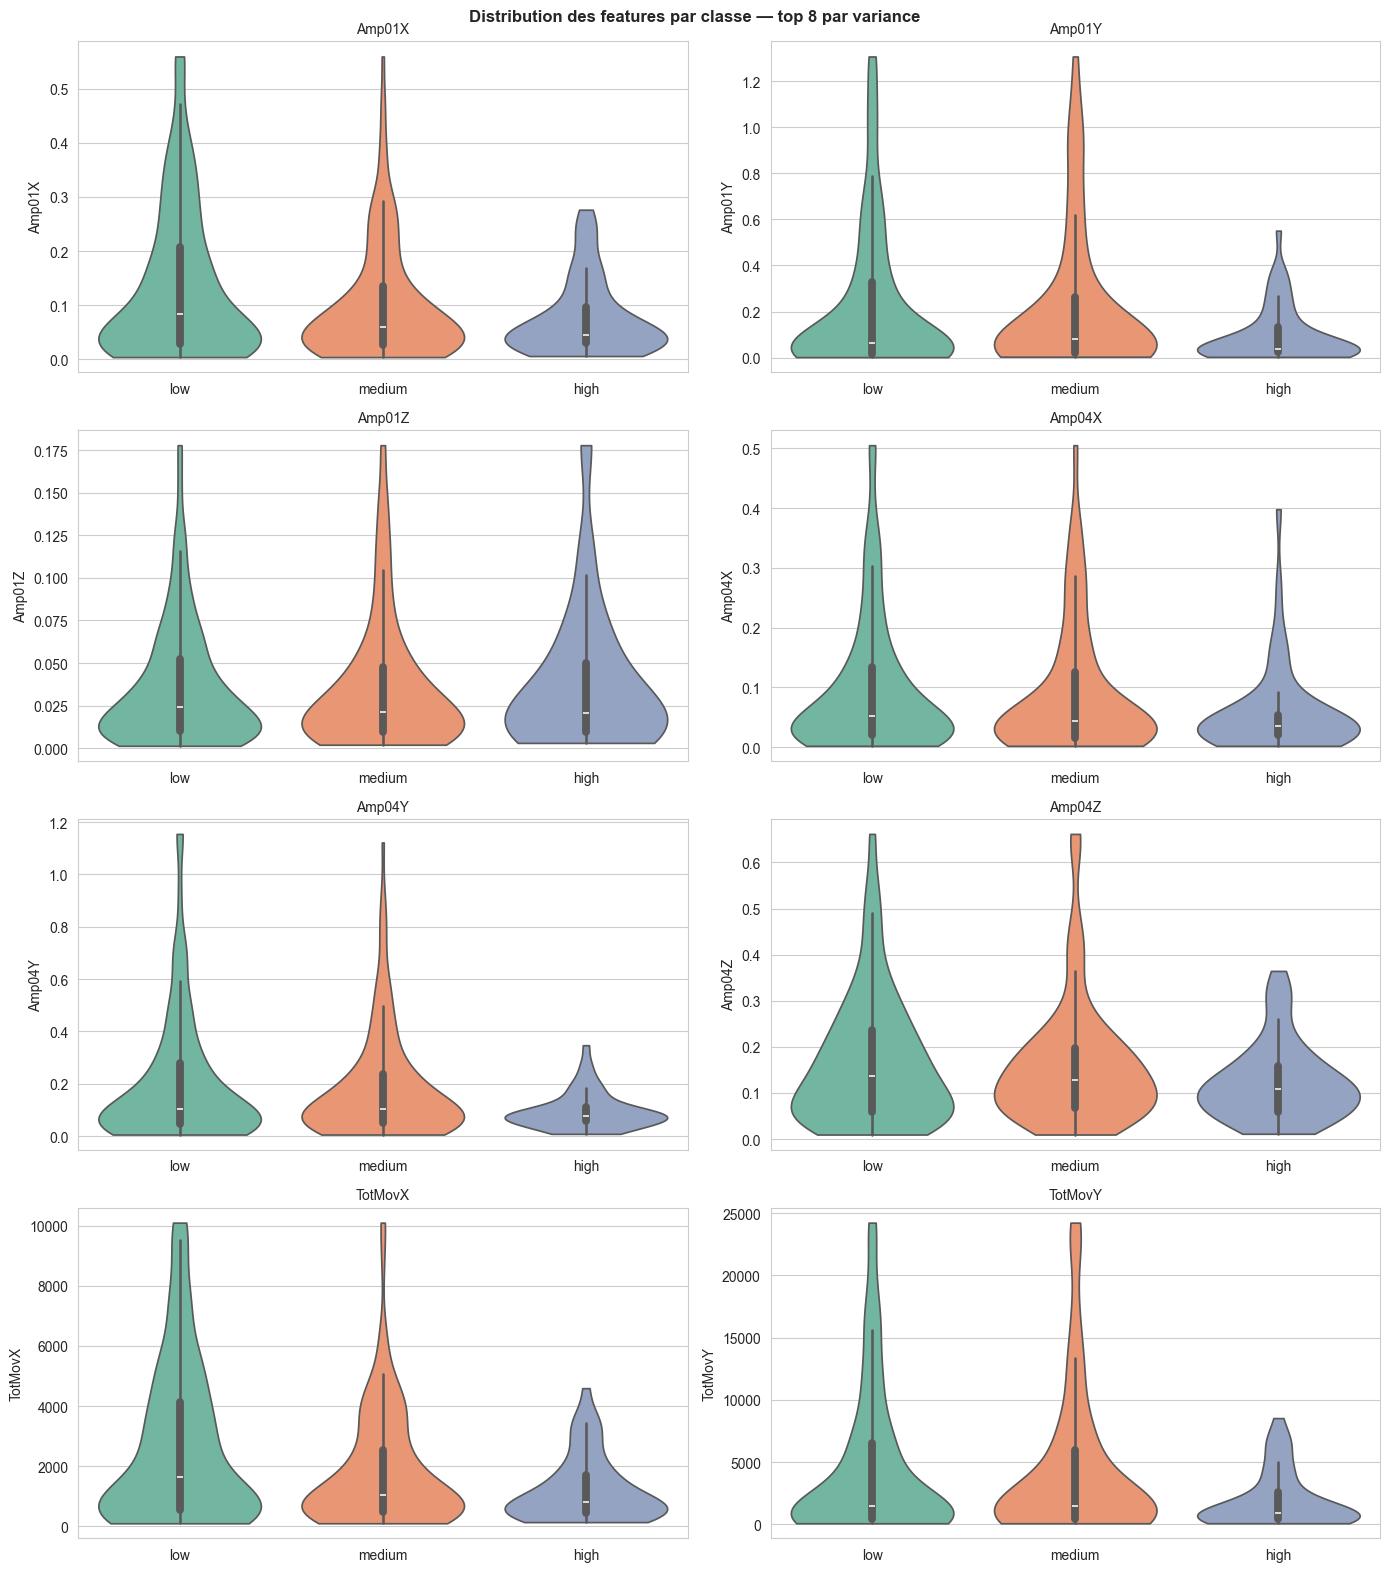

In [7]:
plot_feature_report(dataset_df, feature_cols, MODEL_PROFILE, target_profile=TARGET_PROFILE)

## 6) Optimisation hyperparametres et entrainement

In [8]:
best_params, results_df = run_hyperparam_search(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    model_profile=MODEL_PROFILE,
)

display(results_df.head(10))
print("Best params:", best_params)

final_model = fit_final_model(
    X_train_imp=X_train_imp,
    y_train=y_train,
    X_val_imp=X_val_imp,
    y_val=y_val,
    best_params=best_params,
    model_profile=MODEL_PROFILE,
)

,class_weight,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,val_accuracy,val_f1_weighted
0,balanced,NaN,sqrt,1,2,500,0.457944,0.401548
1,balanced,NaN,log2,1,2,500,0.457944,0.401548
2,balanced,20.0,sqrt,1,2,500,0.457944,0.401548
3,balanced,20.0,log2,1,2,500,0.457944,0.401548
4,balanced,20.0,log2,1,2,200,0.448598,0.400381
5,balanced,20.0,sqrt,1,2,200,0.448598,0.400381
6,balanced,NaN,log2,1,2,200,0.448598,0.400381
7,balanced,NaN,sqrt,1,2,200,0.448598,0.400381
8,balanced,10.0,log2,1,2,500,0.439252,0.397026
9,balanced,10.0,sqrt,1,2,500,0.439252,0.397026


Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


## 7) Evaluation, robustesse et visualisations

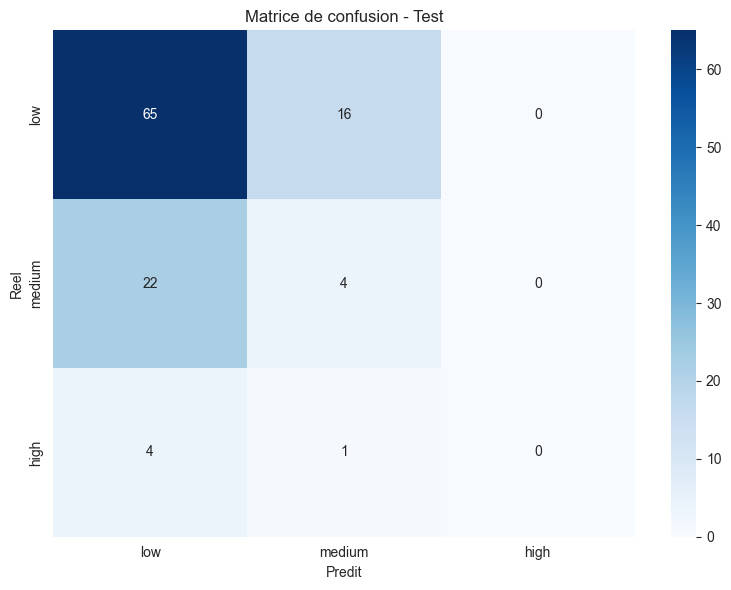

accuracy              0.616071
precision_weighted    0.560799
recall_weighted       0.616071
f1_weighted           0.586129
dtype: float64

Classification report:
              precision    recall  f1-score   support

        high       0.00      0.00      0.00         5
         low       0.71      0.80      0.76        81
      medium       0.19      0.15      0.17        26

    accuracy                           0.62       112
   macro avg       0.30      0.32      0.31       112
weighted avg       0.56      0.62      0.59       112



,subject_id,n,accuracy,f1_weighted
0,BM1997,14.0,0.571429,0.475000
1,CH1308,14.0,0.571429,0.727273
2,FC1997,14.0,0.785714,0.880000
3,NB1934,14.0,0.928571,0.962963
4,NT1234,14.0,0.642857,0.670807
5,RU3300,14.0,0.357143,0.300000
6,ab0710,14.0,0.214286,0.252747
7,rl2704,14.0,0.857143,0.857143


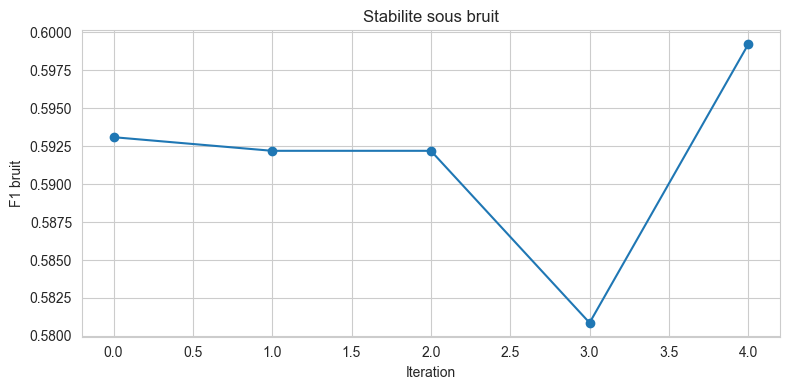

Score robustesse (moyenne): 0.5915072825565524


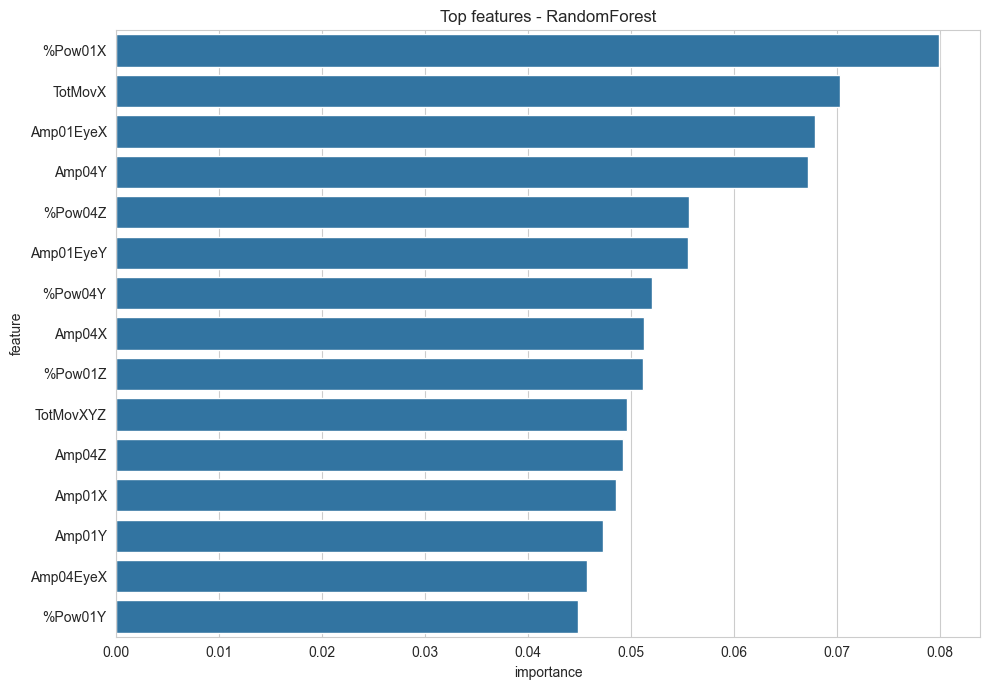

,feature,importance
10,%Pow01X,0.079887
6,TotMovX,0.070272
16,Amp01EyeX,0.067858
4,Amp04Y,0.067142
15,%Pow04Z,0.055626
17,Amp01EyeY,0.055566
14,%Pow04Y,0.052061
3,Amp04X,0.051224
12,%Pow01Z,0.051173
9,TotMovXYZ,0.049567


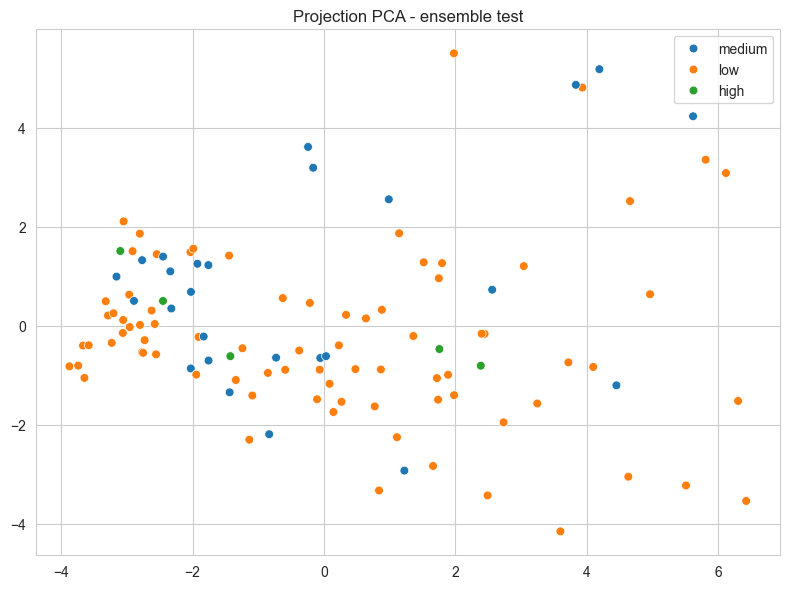

In [9]:
pred_test, metrics, classification_text_report = evaluate_test_set(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    target_profile=TARGET_PROFILE,
    show_plots=True,
)

print(pd.Series(metrics))
if classification_text_report is not None:
    print("\nClassification report:")
    print(classification_text_report)

by_subject = evaluate_by_subject(
    dataset_df=dataset_df,
    test_idx=test_idx,
    y_test=y_test,
    pred_test=pred_test,
    model_profile=MODEL_PROFILE,
)
display(by_subject.head(20))

noise_scores = evaluate_robustness(
    final_model=final_model,
    X_test_imp=X_test_imp,
    y_test=y_test,
    model_profile=MODEL_PROFILE,
    eval_profile=EVAL_PROFILE,
    seed=SEED,
    show_plot=True,
)
print("Score robustesse (moyenne):", float(np.mean(noise_scores)))

imp_df = plot_feature_importance(final_model, feature_cols, top_n=15)
if imp_df is not None:
    display(imp_df.head(20))

plot_pca_if_classification(X_test_imp, y_test, MODEL_PROFILE, seed=SEED)

## 8) Fiche modele

In [10]:
model_card = build_model_card(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    data_profile=DATA_PROFILE,
    best_params=best_params,
    metrics=metrics,
    noise_scores=noise_scores,
    preprocess_profile=PREPROCESS_PROFILE,
)

display(pd.DataFrame([{"field": k, "value": str(v)} for k, v in model_card.items()]))

export_visual_report(
    dataset_df=dataset_df,
    feature_cols=feature_cols,
    model_profile=MODEL_PROFILE,
    output_profile=OUTPUT_PROFILE,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    target_profile=TARGET_PROFILE,
    data_profile=DATA_PROFILE,
    raw_df=raw_df,
    preprocess_profile=PREPROCESS_PROFILE,
    final_model=final_model,
    pred_test=pred_test,
    y_test=y_test,
    metrics=metrics,
    X_test_imp=X_test_imp,
)

,field,value
0,model_name,RandomForest
1,task_type,classification
2,data_source,csv
3,dataset,../data/Indicateurs calculés/FullTimeIndicator...
4,mat_variable,None
5,n_samples,499
6,n_subjects,39
7,n_features,19
8,split_method,group
9,test_size,0.2


{'pages': 8,
 'report_name': 'random_forest_head_report_20260507_150829',
 'pdf_path': '../data/outputs/random_forest\\random_forest_head_report_20260507_150829.pdf',
 'png_dir': '../data/outputs/random_forest\\random_forest_head_report_20260507_150829_png'}